# TinyML - Recurrent Neural Networks (Elman RNN)

**Author:** Thommas Kevin Sales Flores  
**Institution:** Federal University of Rio Grande do Norte  
**Email:** thommas.flores.101@ufrn.edu.br

---
This notebook demonstrates how to build, train, and export **Elman Recurrent Neural Networks** to embedded hardware (Arduino / ESP32).  
All recurrent layers use the Elman (vanilla RNN) cell exclusively.

### Supported building blocks

| Component | Options |
|-----------|--------|
| **Recurrent cell** | `RNN` (Elman) |
| **Activation** | `tanh`, `sigmoid`, `relu`, `softmax`, `leaky_relu`, `gelu`, `swish`, `linear` |
| **Loss** | `mse`, `mae`, `rmse`, `bce`, `cce`, `scce`, `huber` |


## Environment Setup

Uncomment and run the cell below the first time to install dependencies.


In [1]:
#!pip install torch numpy matplotlib scikit-learn

## 1. Setup and Imports


In [2]:
import sys, os
sys.path.append('34_RNN')   # adjust if running from a different directory

import torch
import torch.optim as optim
import numpy as np
from sklearn.datasets import make_moons, make_blobs
from sklearn.model_selection import train_test_split

from model  import RNNModel
from layers import get_activation
from losses import compute_loss, LOSS_NAMES
from utils  import (
    export_to_json,
    train_model,
    plot_training_history,
    plot_regression_uncertainty,
    plot_decision_boundary,
    plot_sequence_prediction,
)
from cpp_generator import generate_ino

print('Available loss functions:', LOSS_NAMES)

os.makedirs('json_model',   exist_ok=True)
os.makedirs('arduino_code', exist_ok=True)

Available loss functions: ['mse', 'mae', 'rmse', 'bce', 'cce', 'scce', 'huber']


---
## 2. Regression Example: 1D Sine with a Gap

We train an Elman RNN to predict `y = sin(x)` with training data only in the intervals  
`[-4, -1.5]` and `[1.5, 4]`. The model is fed a **sequence of length 1** at each call.

> **Architecture choice**: you can freely change `activation` on any layer,  
>  or change the loss to `'mse'`, `'mae'`, or `'huber'`.


=== 1D Regression (Elman RNN, Huber loss) ===
X_train shape: torch.Size([120, 1, 1])   y_train shape: torch.Size([120])
Sample X_train[0]: -4.0   y_train[0]: 0.9494940042495728
  Epoch     1/1500  |  HUBER = 0.188411
  Epoch   300/1500  |  HUBER = 0.004836
  Epoch   600/1500  |  HUBER = 0.004160
  Epoch   900/1500  |  HUBER = 0.004294
  Epoch  1200/1500  |  HUBER = 0.003972
  Epoch  1500/1500  |  HUBER = 0.004230


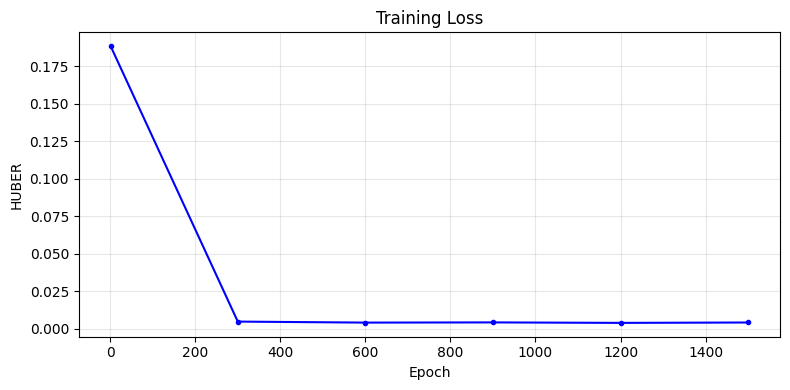

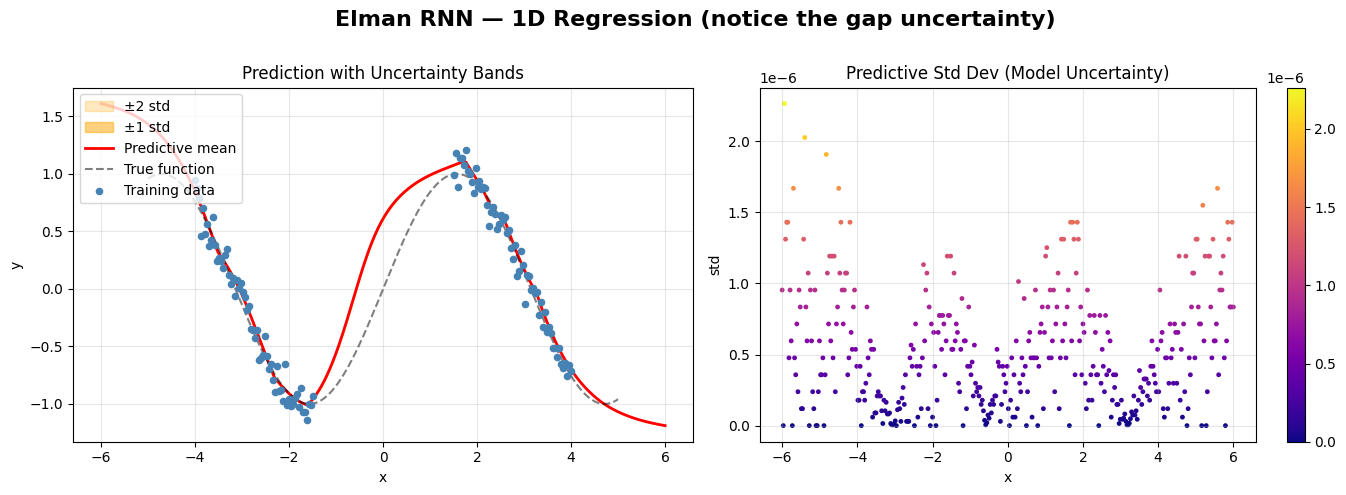

Model exported → json_model/regression_model.json
Generated in : arduino_code/regression_ino  (board: esp32)
Verification  seq_len=4, input_size=1
Expected output (Python) : [0.8662684559822083]


In [3]:
def train_regression():
    print('=== 1D Regression (Elman RNN, Huber loss) ===')
    torch.manual_seed(42)

    # ---- Data ----
    x1 = torch.linspace(-4, -1.5, 60)
    x2 = torch.linspace( 1.5,  4, 60)
    X_train_1d = torch.cat([x1, x2])                  # (120,)
    y_train    = torch.sin(X_train_1d) + 0.1 * torch.randn_like(X_train_1d)
    X_test_1d  = torch.linspace(-5, 5, 200)
    y_test     = torch.sin(X_test_1d)

    # RNN input: (batch, seq_len=1, input_size=1)
    X_train = X_train_1d.view(-1, 1, 1)
    X_test  = X_test_1d.view(-1, 1, 1)

    print('X_train shape:', X_train.shape, '  y_train shape:', y_train.shape)
    print('Sample X_train[0]:', X_train[0].item(), '  y_train[0]:', y_train[0].item())

    # ---- Architecture ----
    model = RNNModel(
        recurrent_layers=[
            {'input_size': 1,  'hidden_size': 64, 'activation': 'tanh'},
            {'input_size': 64, 'hidden_size': 64, 'activation': 'tanh'},
        ],
        dense_layers=[
            {'out_features': 32, 'activation': 'relu'},
            {'out_features': 1,  'activation': 'linear'},
        ],
    )

    optimizer = optim.Adam(model.parameters(), lr=0.01)

    # ---- Train ----
    # Change loss_name to 'mse', 'mae', 'rmse', or 'huber'
    history = train_model(
        model, X_train, y_train, optimizer,
        loss_name='huber', epochs=1500, print_every=300,
        delta=0.5,   # Huber delta (only used by huber loss)
    )
    plot_training_history(history, loss_name='huber')

    # ---- Visualize ----
    plot_regression_uncertainty(
        model, X_train_1d.view(-1, 1), y_train.view(-1, 1),
        X_test_1d.view(-1, 1), y_test.view(-1, 1),
        title='Elman RNN — 1D Regression (notice the gap uncertainty)',
        seq_len=1,
    )

    # ---- Export ----
    export_to_json(model, 'json_model/regression_model.json')
    generate_ino(
        'json_model/regression_model.json',
        'arduino_code/regression_ino',
        board='esp32', task='regression',
    )
    return model


model_reg = train_regression()


---
## 3. Binary Classification: Moon Dataset

Train an Elman RNN on the classic two-moon dataset using **Binary Cross-Entropy** loss.  
Each 2-D point is treated as a sequence of length 1.


=== Binary Classification — Moons (Elman RNN, BCE loss) ===
X_train[0]: [ 1.5184023  -0.55922781]   y_train[0]: 1
  Epoch     1/1000  |  BCE = 0.695586
  Epoch   200/1000  |  BCE = 0.003065
  Epoch   400/1000  |  BCE = 0.000069
  Epoch   600/1000  |  BCE = 0.000030
  Epoch   800/1000  |  BCE = 0.000017
  Epoch  1000/1000  |  BCE = 0.000011


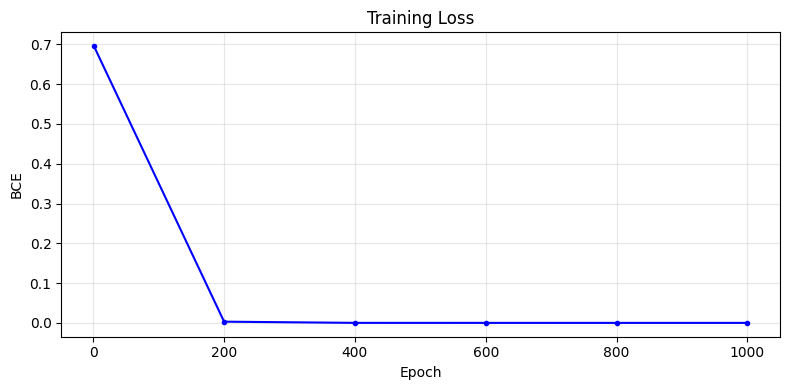

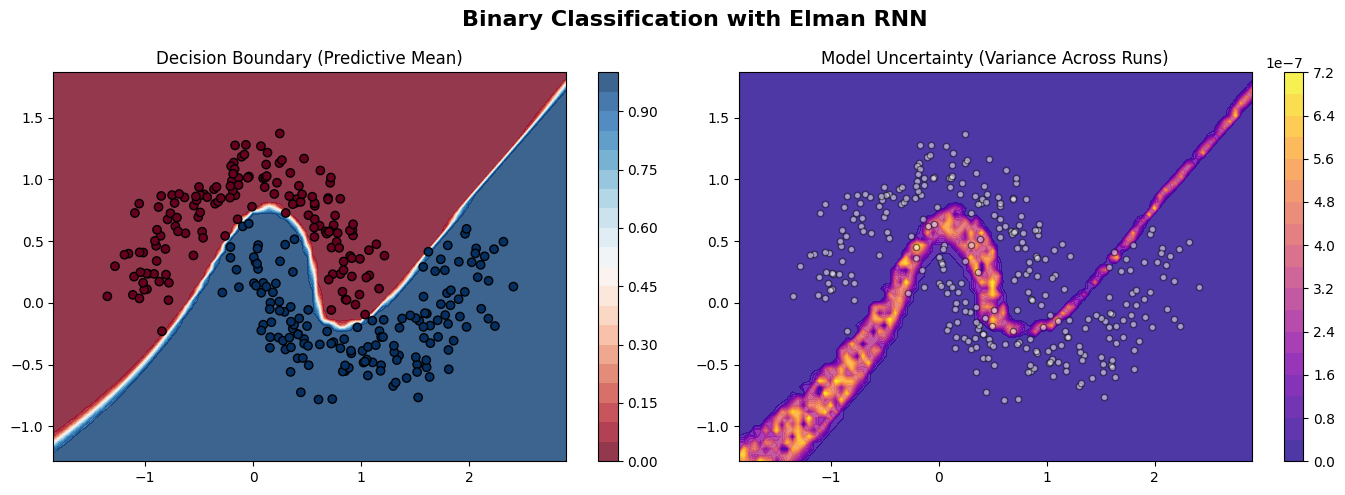

Model exported → json_model/binary_model.json
Generated in : arduino_code/binary_ino  (board: esp32)
Verification  seq_len=4, input_size=2
Expected output (Python) : [10.610983848571777]


In [4]:
def train_binary():
    print('=== Binary Classification — Moons (Elman RNN, BCE loss) ===')
    torch.manual_seed(42)

    # ---- Data ----
    X, y = make_moons(n_samples=300, noise=0.15, random_state=42)
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42)

    print('X_train[0]:', X_tr[0], '  y_train[0]:', y_tr[0])

    # (batch, seq_len=1, input_size=2)
    X_t = torch.FloatTensor(X_tr).unsqueeze(1)
    y_t = torch.FloatTensor(y_tr).view(-1, 1)

    # ---- Architecture ----
    model = RNNModel(
        recurrent_layers=[
            {'input_size': 2,  'hidden_size': 32, 'activation': 'tanh'},
            {'input_size': 32, 'hidden_size': 32, 'activation': 'tanh'},
        ],
        dense_layers=[
            {'out_features': 16, 'activation': 'relu'},
            {'out_features': 1,  'activation': 'linear'},   # logit for BCE
        ],
    )

    optimizer = optim.Adam(model.parameters(), lr=0.01)

    # ---- Train ----
    history = train_model(
        model, X_t, y_t, optimizer,
        loss_name='bce', epochs=1000, print_every=200,
    )
    plot_training_history(history, loss_name='bce')

    # ---- Visualize ----
    plot_decision_boundary(
        model, X, y,
        title='Binary Classification with Elman RNN',
        task='binary', seq_len=1,
    )

    # ---- Export ----
    export_to_json(model, 'json_model/binary_model.json')
    generate_ino(
        'json_model/binary_model.json',
        'arduino_code/binary_ino',
        board='esp32', task='binary',
    )
    return model


model_bin = train_binary()


---
## 4. Multiclass Classification: Blobs Dataset

Train an Elman RNN on three Gaussian clusters using  
**Sparse Categorical Cross-Entropy** (integer labels, no one-hot encoding required).


=== Multiclass Classification — Blobs (Elman RNN, SCCE loss) ===
X_train[0]: [-2.62485019  9.52601409]   y_train[0]: 0
  Epoch     1/1000  |  SCCE = 1.044644
  Epoch   200/1000  |  SCCE = 0.000026
  Epoch   400/1000  |  SCCE = 0.000017
  Epoch   600/1000  |  SCCE = 0.000011
  Epoch   800/1000  |  SCCE = 0.000008
  Epoch  1000/1000  |  SCCE = 0.000006


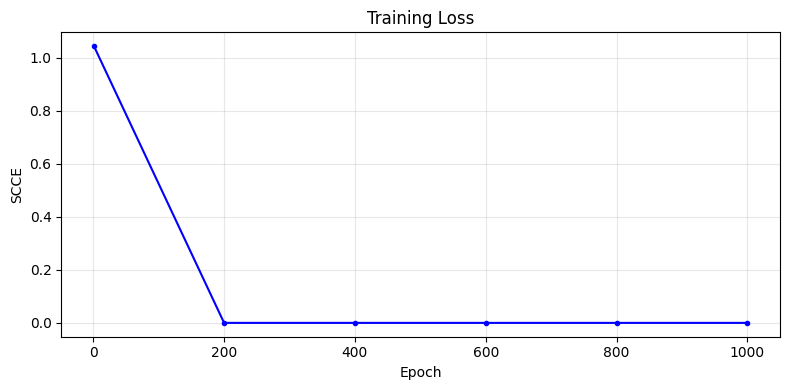

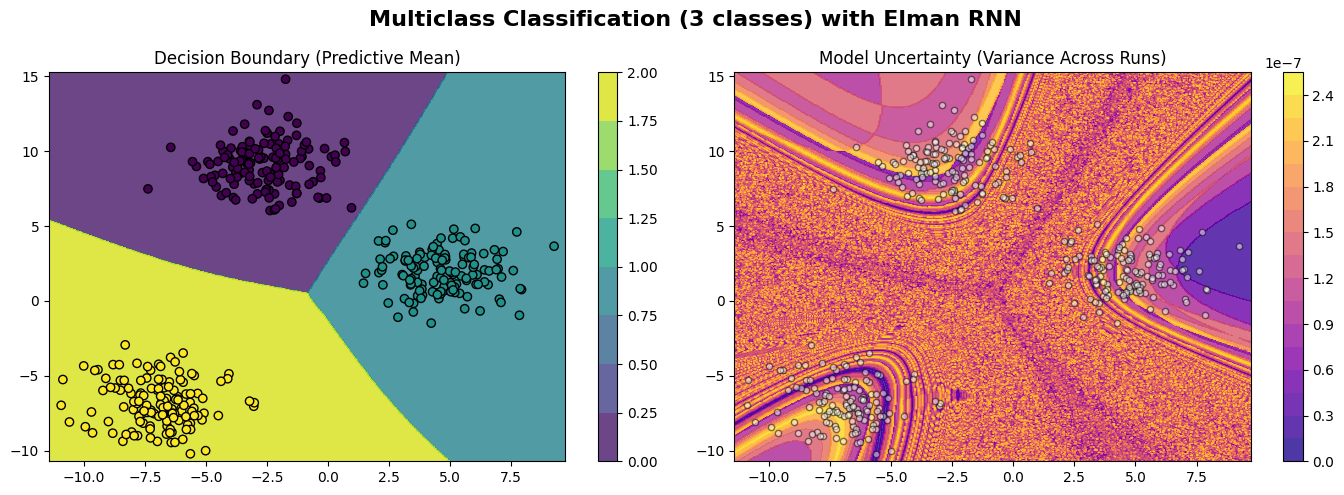

Model exported → json_model/multiclass_model.json
Generated in : arduino_code/multiclass_ino  (board: esp32)
Verification  seq_len=4, input_size=2
Expected output (Python) : [-3.897493362426758, 4.094757080078125, -4.046463489532471]


In [5]:
def train_multiclass():
    print('=== Multiclass Classification — Blobs (Elman RNN, SCCE loss) ===')
    torch.manual_seed(42)

    # ---- Data ----
    X, y = make_blobs(n_samples=400, centers=3, cluster_std=1.5, random_state=42)
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42)

    print('X_train[0]:', X_tr[0], '  y_train[0]:', y_tr[0])

    X_t = torch.FloatTensor(X_tr).unsqueeze(1)   # (batch, 1, 2)
    y_t = torch.LongTensor(y_tr)                  # integer labels

    # ---- Architecture ----
    model = RNNModel(
        recurrent_layers=[
            {'input_size': 2, 'hidden_size': 32, 'activation': 'tanh'},
        ],
        dense_layers=[
            {'out_features': 16, 'activation': 'relu'},
            {'out_features': 3,  'activation': 'linear'},   # 3 classes
        ],
    )

    optimizer = optim.Adam(model.parameters(), lr=0.01)

    # ---- Train ----
    history = train_model(
        model, X_t, y_t, optimizer,
        loss_name='scce', epochs=1000, print_every=200,
    )
    plot_training_history(history, loss_name='scce')

    # ---- Visualize ----
    plot_decision_boundary(
        model, X, y,
        title='Multiclass Classification (3 classes) with Elman RNN',
        task='multiclass', seq_len=1,
    )

    # ---- Export ----
    export_to_json(model, 'json_model/multiclass_model.json')
    generate_ino(
        'json_model/multiclass_model.json',
        'arduino_code/multiclass_ino',
        board='esp32', task='multiclass',
    )
    return model


model_multi = train_multiclass()


---
## 5. Sequence-to-Sequence Example: Noisy Sine Prediction

A true sequence task: the model receives a window of `T` steps and must predict the next step at every position.  
Uses `forward_sequence()` to obtain per-step outputs.  
Two stacked Elman RNN layers are used to demonstrate depth in the recurrent stack.


=== Seq-to-Seq Sine Prediction (Elman RNN, MSE loss) ===
X shape: torch.Size([500, 30, 1])   Y shape: torch.Size([500, 30])
  Epoch    1/500  |  MSE = 0.504714
  Epoch  100/500  |  MSE = 0.002176
  Epoch  200/500  |  MSE = 0.002015
  Epoch  300/500  |  MSE = 0.001933
  Epoch  400/500  |  MSE = 0.001702
  Epoch  500/500  |  MSE = 0.002224


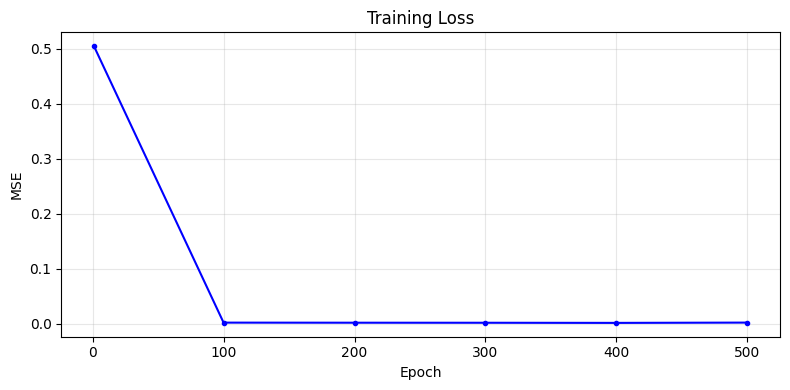

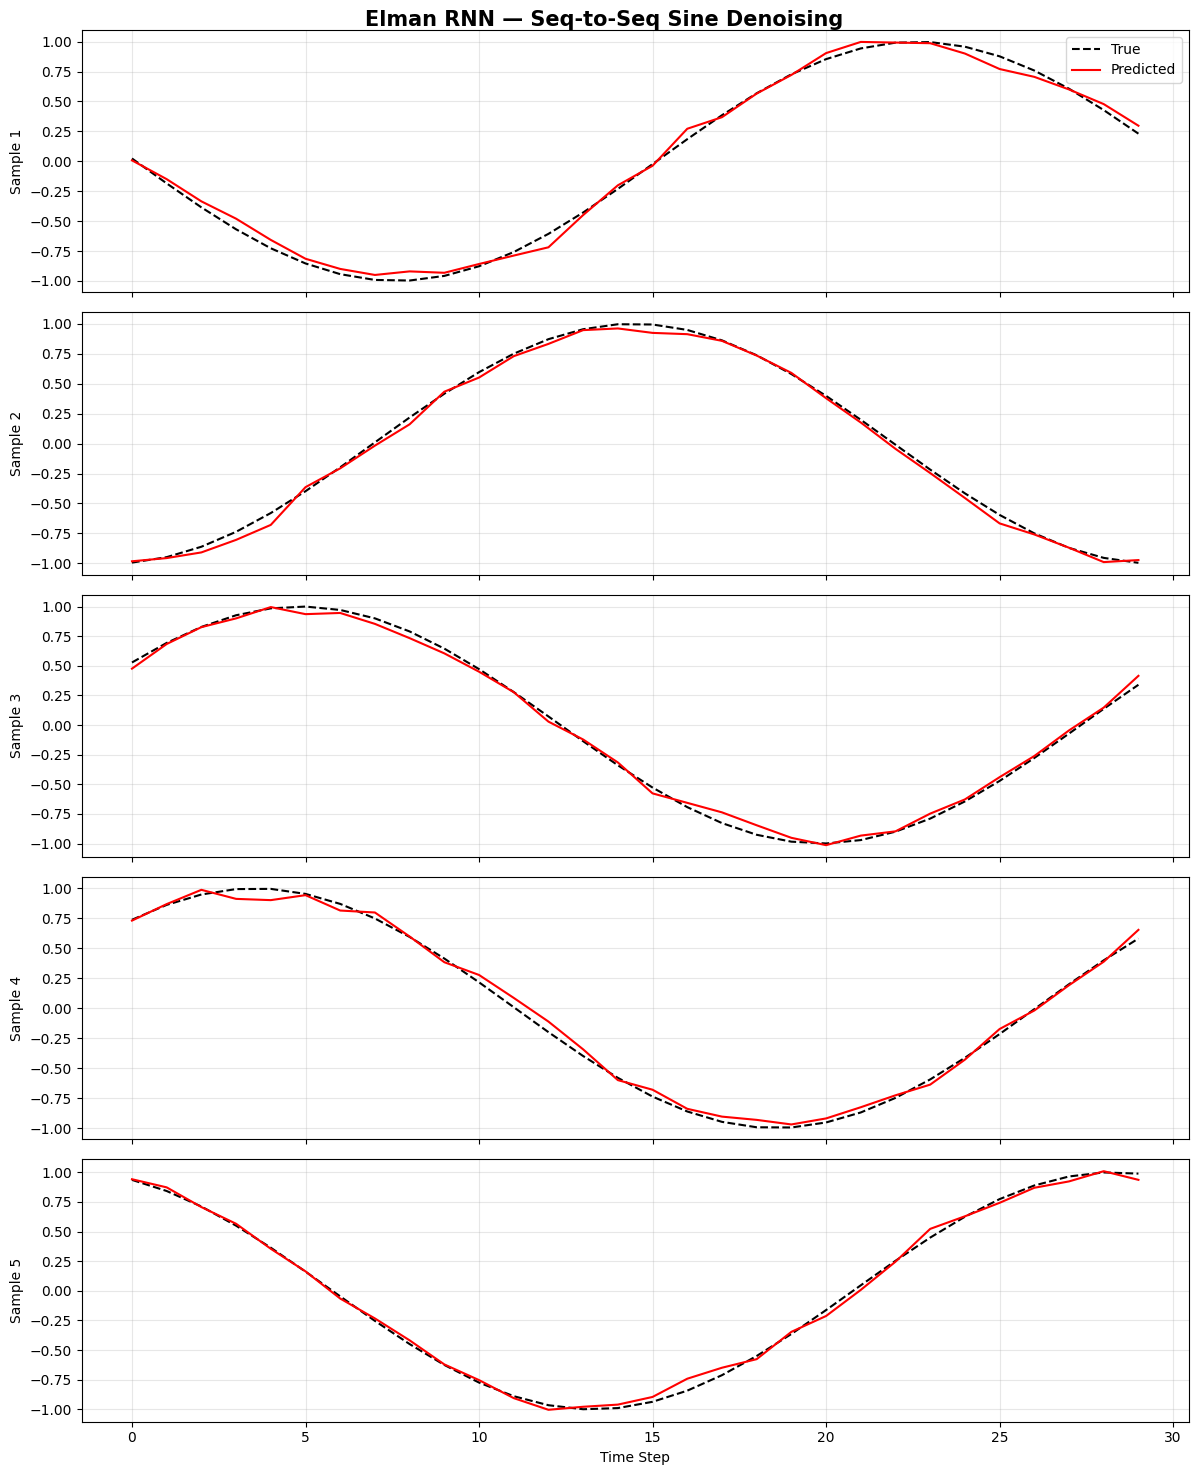

Model exported → json_model/seq2seq_model.json
Generated in : arduino_code/seq2seq_ino  (board: esp32)
Verification  seq_len=4, input_size=1
Expected output (Python) : [1.6722476482391357]


In [6]:
def train_seq2seq():
    print('=== Seq-to-Seq Sine Prediction (Elman RNN, MSE loss) ===')
    torch.manual_seed(0)

    T      = 30          # sequence length
    N      = 500         # number of sequences
    noise  = 0.05

    # Each sequence: sin(t) for t in [start, start+T]
    starts = torch.rand(N) * 2 * np.pi
    t_vals = torch.arange(T).float() / T * 2 * np.pi   # (T,)

    X_np = np.stack(
        [np.sin(starts[i].item() + t_vals.numpy()) + noise * np.random.randn(T)
         for i in range(N)]
    )   # (N, T)
    Y_np = np.stack(
        [np.sin(starts[i].item() + t_vals.numpy()) for i in range(N)]
    )   # (N, T) — clean target

    X = torch.FloatTensor(X_np).unsqueeze(-1)   # (N, T, 1)
    Y = torch.FloatTensor(Y_np)                  # (N, T)

    print('X shape:', X.shape, '  Y shape:', Y.shape)

    # ---- Architecture ----
    model = RNNModel(
        recurrent_layers=[
            {'input_size': 1,  'hidden_size': 64, 'activation': 'tanh'},
            {'input_size': 64, 'hidden_size': 32, 'activation': 'tanh'},
        ],
        dense_layers=[
            {'out_features': 1, 'activation': 'linear'},
        ],
    )

    optimizer = optim.Adam(model.parameters(), lr=5e-3)

    # ---- Seq-to-seq training loop ----
    history = []
    epochs  = 500
    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()
        # forward_sequence returns (N, T, 1)
        out  = model.forward_sequence(X).squeeze(-1)   # (N, T)
        loss = compute_loss('mse', out, Y)
        loss.backward()
        optimizer.step()
        if epoch % 100 == 0 or epoch == 1:
            print(f'  Epoch {epoch:>4}/{epochs}  |  MSE = {loss.item():.6f}')
            history.append((epoch, loss.item()))

    plot_training_history(history, loss_name='mse')

    # ---- Visualize predictions on 5 samples ----
    plot_sequence_prediction(
        model, X[:5], Y[:5],
        title='Elman RNN — Seq-to-Seq Sine Denoising',
        n_display=5,
    )

    # ---- Export (only last-step prediction → regression) ----
    export_to_json(model, 'json_model/seq2seq_model.json')
    generate_ino(
        'json_model/seq2seq_model.json',
        'arduino_code/seq2seq_ino',
        board='esp32', task='regression',
    )
    return model


model_s2s = train_seq2seq()


---
## 6. Quick Reference — Changing Activations & Losses

### Activation functions (use in `dense_layers` or RNN cell `activation` key)

| Name | Key string |
|------|------------|
| Tanh | `'tanh'` |
| Sigmoid | `'sigmoid'` |
| ReLU | `'relu'` |
| Softmax | `'softmax'` |
| Leaky ReLU | `'leaky_relu'` |
| GELU | `'gelu'` |
| Swish | `'swish'` |
| Linear (identity) | `'linear'` |

### Loss functions (pass as `loss_name` to `train_model` or `compute_loss`)

| Name | Key string | Use case |
|------|------------|----------|
| Mean Squared Error | `'mse'` | Regression |
| Mean Absolute Error | `'mae'` | Regression (robust) |
| Root MSE | `'rmse'` | Regression |
| Binary Cross-Entropy | `'bce'` | Binary classification |
| Categorical Cross-Entropy | `'cce'` | Multiclass (one-hot targets) |
| Sparse CCE | `'scce'` | Multiclass (integer targets) |
| Huber | `'huber'` | Regression (less sensitive to outliers) |

### Example: build a two-layer Elman RNN with GELU dense activation and Huber loss

```python
model = RNNModel(
    recurrent_layers=[
        {'input_size': 4, 'hidden_size': 128, 'activation': 'tanh'},
    ],
    dense_layers=[
        {'out_features': 64, 'activation': 'gelu'},
        {'out_features': 1,  'activation': 'linear'},
    ],
)

optimizer = optim.Adam(model.parameters(), lr=1e-3)
history = train_model(model, X_train, y_train, optimizer,
                      loss_name='huber', epochs=500, delta=1.0)
```
